Домашняя работа 5
Онищенко Геннадий 336883

# 0. Импорт библиотец

Прежде чем начать, импортируем библиотеки.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno

# 1. Используйте датасет после обработки пропусков (из ДЗ 4).

In [3]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/loan_prediction_dataset.csv')
for c in df.select_dtypes(include=['int64', 'float64']).columns:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].median())

for c in df.select_dtypes(include=['object']).columns:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].mode()[0])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Сделали то же самое действие, что и  в конце прошлой домашки. Заполнили числовые пропуски медианой, а категориальные модой.

---



# 2. Найти выбросы для ApplicantIncome и LoanAmount двумя способами:

IQR-правило

метод стандартного отклонения (std)

1. Метод IQR.


> Q1 = 25-й процентиль (нижний квартиль)
Q3 = 75-й процентиль (верхний квартиль)
IQR = Q3 - Q1
Границы: [Q1 - 1.5×IQR, Q3 + 1.5×IQR]









In [44]:
my_application = df['ApplicantIncome']
my_loan = df['LoanAmount']
def iqr(data, column_name):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_border = Q1 - 1.5 * IQR
    upper_border = Q3 + 1.5 * IQR
    outs = data[(data < lower_border) | (data > upper_border)]

    print(f" {column_name} IQR")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Нижняя граница: {lower_border:.2f}")
    print(f"Верхняя граница: {upper_border:.2f}")
    print(f"Количество выбросов: {len(outs)}")
    return outs

iqr(my_application, 'ApplicantIncome')
print(iqr(my_application, 'ApplicantIncome'))
iqr(my_loan, 'LoanAmount')
print(iqr(my_loan, 'LoanAmount'))

 ApplicantIncome IQR
Q1: 2877.50
Q3: 5795.00
IQR: 2917.50
Нижняя граница: -1498.75
Верхняя граница: 10171.25
Количество выбросов: 50
 ApplicantIncome IQR
Q1: 2877.50
Q3: 5795.00
IQR: 2917.50
Нижняя граница: -1498.75
Верхняя граница: 10171.25
Количество выбросов: 50
9      12841
34     12500
54     11500
67     10750
102    13650
106    11417
115    14583
119    10408
126    23803
128    10513
130    20166
138    14999
144    11757
146    14866
155    39999
171    51763
183    33846
185    39147
191    12000
199    11000
254    16250
258    14683
271    11146
278    14583
284    20667
308    20233
324    15000
333    63337
369    19730
370    15759
409    81000
424    14880
432    12876
438    10416
443    37719
467    16692
475    16525
478    16667
483    10833
487    18333
493    17263
506    20833
509    13262
525    17500
533    11250
534    18165
561    19484
572    16666
594    16120
604    12000
Name: ApplicantIncome, dtype: int64
 LoanAmount IQR
Q1: 100.25
Q3: 164.75
IQR: 64.50

Первым делом создали переменные для двух наших столбцов соответственно. Мы вычисляем квартили, затем вычисляем тот что за них выходит и фиксируем как выбросы. а во втором - верхняя и нижняя границы. Если значения выходят за заданные, то они считаются выбросами. в итоге выводим основную инфу по выбросам и сами выбросы


2. Метод стандартного отклонения

In [45]:
def std(data, column_name, n_std=3):
    mean = data.mean()
    std = data.std()
    lower_border = mean - n_std * std
    upper_border = mean + n_std * std
    outs = data[(data < lower_border) | (data > upper_border)]

    print(f"{column_name} Std")
    print(f"Среднее: {mean:.2f}")
    print(f"std отклонение: {std:.2f}")
    print(f"Нижняя граница: {lower_border:.2f}")
    print(f"Верхняя граница: {upper_border:.2f}")
    print(f"Количество выбросов: {len(outs)}")
    return outs

std(my_application, 'ApplicantIncome')
print(std(my_application, 'ApplicantIncome'))
std(my_loan, 'LoanAmount')
print(std(my_loan, 'LoanAmount'))

ApplicantIncome Std
Среднее: 5403.46
std отклонение: 6109.04
Нижняя граница: -12923.67
Верхняя граница: 23730.58
Количество выбросов: 8
ApplicantIncome Std
Среднее: 5403.46
std отклонение: 6109.04
Нижняя граница: -12923.67
Верхняя граница: 23730.58
Количество выбросов: 8
126    23803
155    39999
171    51763
183    33846
185    39147
333    63337
409    81000
443    37719
Name: ApplicantIncome, dtype: int64
LoanAmount Std
Среднее: 145.75
std отклонение: 84.11
Нижняя граница: -106.57
Верхняя граница: 398.07
Количество выбросов: 15
LoanAmount Std
Среднее: 145.75
std отклонение: 84.11
Нижняя граница: -106.57
Верхняя граница: 398.07
Количество выбросов: 15
130    650.0
155    600.0
171    700.0
177    495.0
278    436.0
308    480.0
333    490.0
369    570.0
432    405.0
487    500.0
506    480.0
523    480.0
525    400.0
561    600.0
604    496.0
Name: LoanAmount, dtype: float64


# 3. Сравнить пересечение и расхождения списков наблюдений; кратко объяснить причины различий

 Исходя из полученных выше данных можно сделать вывод, что по методу iqr выбросов находится значительно больше чем по std: 8 против 50 и15 против 41. Такая разница обусловлена в сути подходов. iqr основан на квартилях, а std на нормальных значениях отклонений, что говорит о том, что std фиксирует только совсем явные отклонения, в то время как iqr вообще все. Об этом также говорит, что все выбросы из std также есть в iqr (путем визуального совмещения сделан вывод). Поэтому да, методы разные, для разных целей видимо применяются.


# 4. Визуально подтвердить наличие выбросов (boxplot / гистограммы)

Вboxplot буквально основан на IQR поэтому проблем не будет. Все точки за пределами усов являются выбросами. Сделаем для ApplicatioIncome и Loan jnltkmyst ,jrcgkjns/

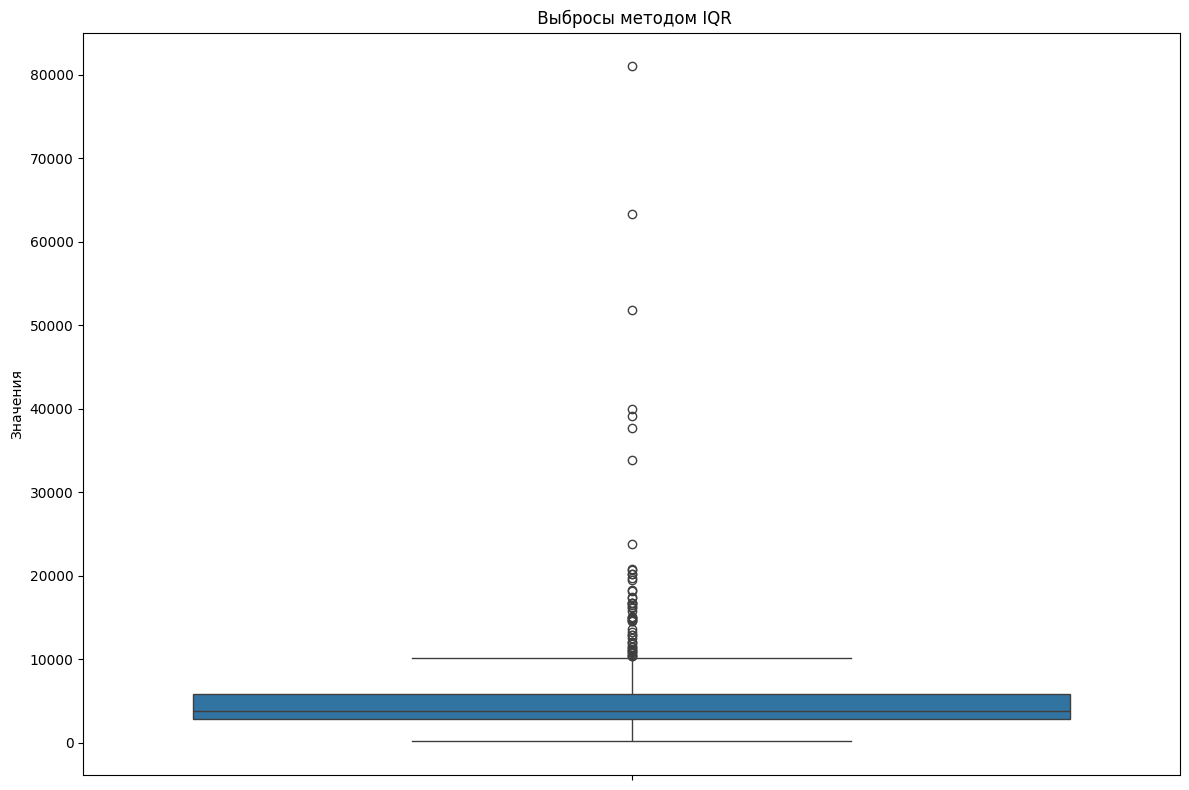

In [54]:
plt.figure(figsize=(12, 8))
sns.boxplot(my_application)
plt.title(' Выбросы методом IQR')
plt.ylabel('Значения')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


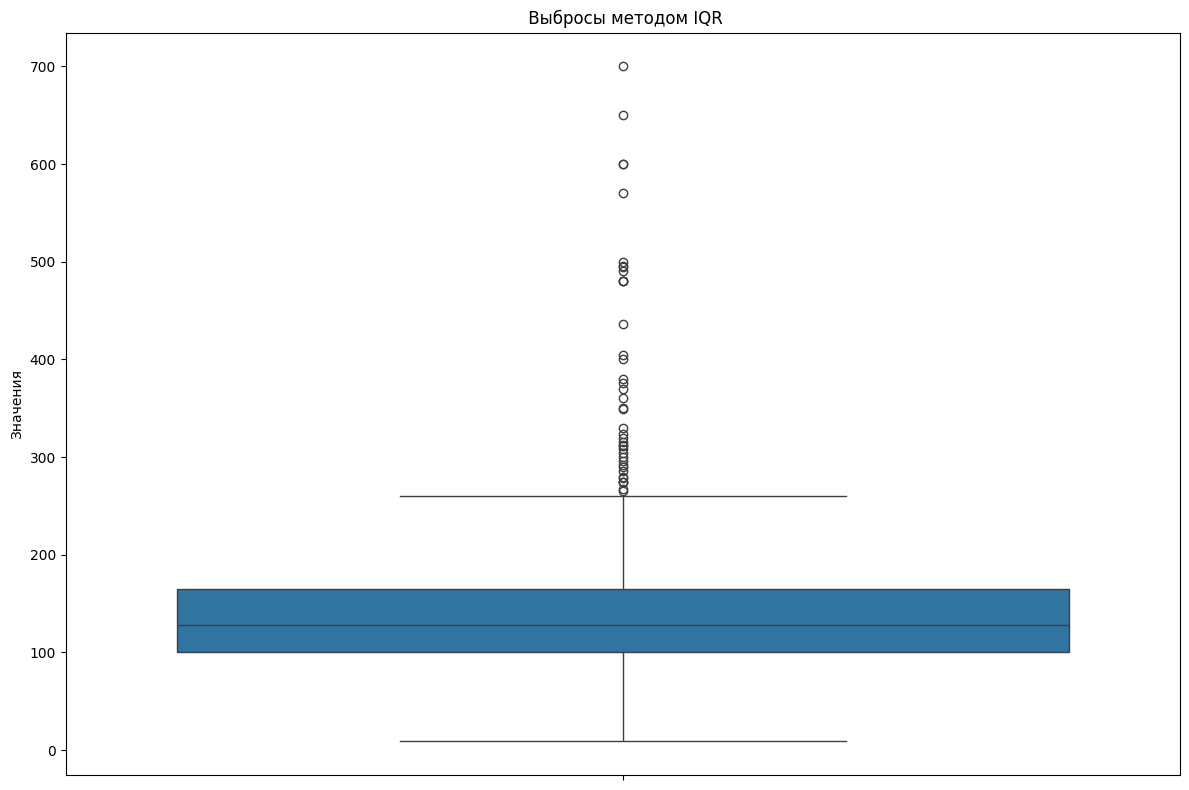

In [55]:
plt.figure(figsize=(12, 8))
sns.boxplot(my_loan)
plt.title(' Выбросы методом IQR')
plt.ylabel('Значения')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 5. Принять решение:

удалить выбросы,
заменить,
оставить
Обосновать выбор

Судя по боксплотам выбросы в столбцах LoanAmount и ApplicationIncome не являются случайностями, а несут в себе вполне важную информацию о важных клиентах, поэтому совсем некорректно будет эти данные удалять. Заменять данные на более ласковые тоже мне кажется неуместно, нет смысла сглаживать показатели просто ради сглаживания, эти выбросы несут в себе информацию. Поэтому я их оставлю.


# 6. Предложить варианты кодирования категориальных переменных, обосновать выбор
7. Применить выбранные правила перекодирования

чтобы преобразовать категориальные признаки рассмотрены три подхода: Label Encoding (замена категорий на последовательные числа), One-Hot Encoding (создание отдельных столбцов 0/1 для каждой категории) и ручное бинарное кодирование (для двухзначных признаков). Бинарные переменные (Gender, Married, Education, Self_Employed, Loan_Status) закодированы значениями 0/1, так как это компактный метод без увеличения количества признаков. Property_Area преобразован по порядку урбанизации.

In [63]:
binary_mapping = {
    'Gender': {'Male': 1, 'Female': 0},
    'Married': {'Yes': 1, 'No': 0},
    'Education': {'Graduate': 1, 'Not Graduate': 0},
    'Self_Employed': {'Yes': 1, 'No': 0},
    'Loan_Status': {'Y': 1, 'N': 0}
}

for c, mapping in binary_mapping.items():
    if c in df.columns:
        df[c] = df[c].map(mapping).fillna(0)

if 'Property_Area' in df.columns:
    df['Property_Area'] = df['Property_Area'].map({
        'Rural': 0, 'Semiurban': 1, 'Urban': 2
    }).fillna(1)
if 'Loan_ID' in df.columns:
    df.set_index('Loan_ID', inplace=True)


df.head()


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,0.0,0.0,0,0.0,0.0,5849,0.0,128.0,360.0,1.0,1.0,0.0
LP001003,0.0,0.0,1,0.0,0.0,4583,1508.0,128.0,360.0,1.0,1.0,0.0
LP001005,0.0,0.0,0,0.0,0.0,3000,0.0,66.0,360.0,1.0,1.0,0.0
LP001006,0.0,0.0,0,0.0,0.0,2583,2358.0,120.0,360.0,1.0,1.0,0.0
LP001008,0.0,0.0,0,0.0,0.0,6000,0.0,141.0,360.0,1.0,1.0,0.0


# 8. Сделать проверку


In [66]:
print(f"Размер датасета: {df.shape[0]} строк × {df.shape[1]} столбцов")
print(f"Строк: {df.shape[0]:,}, Столбцов: {df.shape[1]}")

print("Типы данных после кодирования:")
print(df.dtypes)

print("Пропуски в данных:")
propuski = df.isnull().sum()
if propuski.sum() == 0:
    print("Пропусков нет — данные чистые")
else:
    print(propuski[propuski > 0])

print("Первые 5 записей после обработки:")
print(df.head().round(2))


Размер датасета: 614 строк × 12 столбцов
Строк: 614, Столбцов: 12
Типы данных после кодирования:
Gender               float64
Married              float64
Dependents            object
Education            float64
Self_Employed        float64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area        float64
Loan_Status          float64
dtype: object
Пропуски в данных:
Пропусков нет — данные чистые
Первые 5 записей после обработки:
          Gender  Married Dependents  Education  Self_Employed  \
Loan_ID                                                          
LP001002     0.0      0.0          0        0.0            0.0   
LP001003     0.0      0.0          1        0.0            0.0   
LP001005     0.0      0.0          0        0.0            0.0   
LP001006     0.0      0.0          0        0.0            0.0   
LP001008     0.0      0.0          0        0.0            0.0

 провели проверку данных, типы, пропуски и тд. ошибок не обнаружено